In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import os, shutil
import matplotlib.pyplot as plt
from datetime import datetime
from PIL import Image
import torch.nn.functional as F
import torchvision.models as models

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [18]:
%%bash
curl -L -o /content/pizza-not-pizza.zip \
  https://www.kaggle.com/api/v1/datasets/download/carlosrunner/pizza-not-pizza

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  100M  100  100M    0     0  10.7M      0  0:00:09  0:00:09 --:--:-- 16.4M


In [19]:
!unzip -q pizza-not-pizza.zip -d pizza-not-pizza

In [63]:
data_dir    = "pizza-not-pizza/pizza_not_pizza"
num_classes = 2
batch_size  = 32
epochs  = 20
learning_rate          = 1e-4

train_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(data_dir)

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform   = val_transforms

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

print(f"Train samples: {train_size} | Val samples: {val_size}")
print(f"Classes: {full_dataset.classes}")

Train samples: 1572 | Val samples: 394
Classes: ['not_pizza', 'pizza']


In [64]:
model = models.inception_v3(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)

model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20] Train Loss: 0.2995 | Val Loss: 0.1635 | Val Accuracy: 94.67%
Epoch [2/20] Train Loss: 0.0672 | Val Loss: 0.1568 | Val Accuracy: 94.67%
Epoch [3/20] Train Loss: 0.0334 | Val Loss: 0.1578 | Val Accuracy: 94.92%
Epoch [4/20] Train Loss: 0.0395 | Val Loss: 0.1726 | Val Accuracy: 94.92%
Epoch [5/20] Train Loss: 0.0176 | Val Loss: 0.1814 | Val Accuracy: 94.42%
Epoch [6/20] Train Loss: 0.0431 | Val Loss: 0.2120 | Val Accuracy: 95.69%
Epoch [7/20] Train Loss: 0.0210 | Val Loss: 0.1765 | Val Accuracy: 95.18%
Epoch [8/20] Train Loss: 0.0146 | Val Loss: 0.1879 | Val Accuracy: 95.18%
Epoch [9/20] Train Loss: 0.0166 | Val Loss: 0.2204 | Val Accuracy: 93.65%
Epoch [10/20] Train Loss: 0.0624 | Val Loss: 0.1916 | Val Accuracy: 94.92%
Epoch [11/20] Train Loss: 0.1100 | Val Loss: 0.1683 | Val Accuracy: 94.67%
Epoch [12/20] Train Loss: 0.0242 | Val Loss: 0.1823 | Val Accuracy: 95.69%
Epoch [13/20] Train Loss: 0.0076 | Val Loss: 0.1922 | Val Accuracy: 95.69%
Epoch [14/20] Train Loss: 0.0072 |

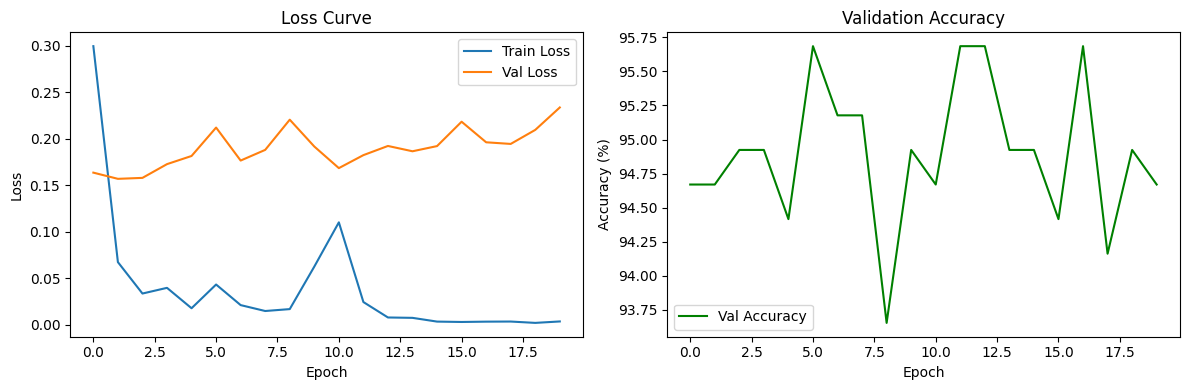

In [80]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate
)

train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs, aux_outputs = model(inputs)
        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux_outputs, labels)
        loss  = loss1 + 0.4 * loss2

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    accuracy     = 100 * correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Accuracy: {accuracy:.2f}%")

timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join("models", f"inception_pizza_{timestamp}_ep{epochs}")
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "model.pth")
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Loss Curve"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, color="green", label="Val Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy"); plt.legend()

plt.tight_layout()
plot_path = os.path.join(save_dir, "training_results.png")
plt.savefig(plot_path)
plt.show()

In [83]:
classes = ["not_pizza", "pizza"]

model_path = 'models/inception_pizza_20260323_200108_ep20/model.pth'

model = models.inception_v3(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 2)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval().to(device)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [84]:
def predict_image(image_path):
  transform = transforms.Compose([
  transforms.Resize((299, 299)),
  transforms.ToTensor(),
  transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])])

  img    = Image.open(image_path).convert("RGB")
  tensor = transform(img).unsqueeze(0).to(device)

  with torch.no_grad():
      output      = model(tensor)
      probs       = F.softmax(output, dim=1)[0]
      confidence, pred = torch.max(probs, 0)

  predicted_class = classes[pred.item()]
  percentages     = [p.item() * 100 for p in probs]

  fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))

  ax_img.imshow(img)
  ax_img.axis("off")
  ax_img.set_title(
      f"Prediction: {predicted_class.upper()}\n{confidence.item()*100:.1f}% confident",
      fontsize=14,
      fontweight="bold",
      color="green" if predicted_class == "pizza" else "red"
  )

  colors = ["tomato" if c == predicted_class else "lightgray" for c in classes]
  bars   = ax_bar.bar(classes, percentages, color=colors, edgecolor="black", width=0.4)
  ax_bar.set_ylim(0, 110)
  ax_bar.set_ylabel("Confidence (%)", fontsize=12)
  ax_bar.set_title("Class Probabilities", fontsize=13)

  for bar, pct in zip(bars, percentages):
      ax_bar.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height() + 2,
          f"{pct:.1f}%",
          ha="center", va="bottom",
          fontsize=13, fontweight="bold"
      )

  plt.tight_layout()
  plt.show()
  print(f"Prediction: {predicted_class} ({confidence.item()*100:.1f}%)")

In [71]:
# Dowload pizza image
!curl -o pizza_image.jpg "https://upload.wikimedia.org/wikipedia/commons/9/91/Pizza-3007395.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3138k  100 3138k    0     0  8671k      0 --:--:-- --:--:-- --:--:-- 8669k


In [78]:
#Download pizza image 2
!curl -L -o pizza_image2.jpg "https://amici.ph/cdn/shop/files/CLASSICPEPPERONI_1200x.jpg?v=1747245899"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  442k  100  442k    0     0  2252k      0 --:--:-- --:--:-- --:--:-- 2255k


In [73]:
# Download burger image
!curl -L -o burger_image.jpg "https://img.freepik.com/free-photo/classic-cheese-burger-with-beef-cutlet-vegetables-onions-isolated-white-background_123827-29709.jpg?semt=ais_hybrid&w=740&q=80"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80792  100 80792    0     0   779k      0 --:--:-- --:--:-- --:--:--  781k


In [74]:
# Download steak image
!curl -L -o steak_image.jpg "https://www.southernliving.com/thmb/kvc-GEET2S2yZL5WK1H-J_dg_kM=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/Cowboy_Steaks_004-293d0925063f493e943a7c501f5cbc6e.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  192k  100  192k    0     0  1292k      0 --:--:-- --:--:-- --:--:-- 1299k


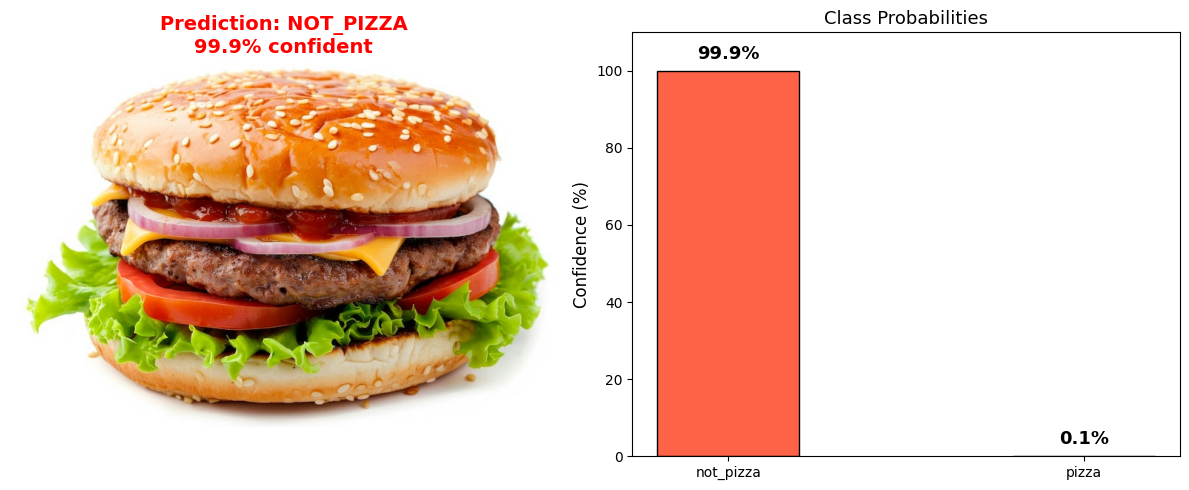

Prediction: not_pizza (99.9%)


In [90]:
image_dir = 'burger_image.jpg'

predict_image(image_dir)

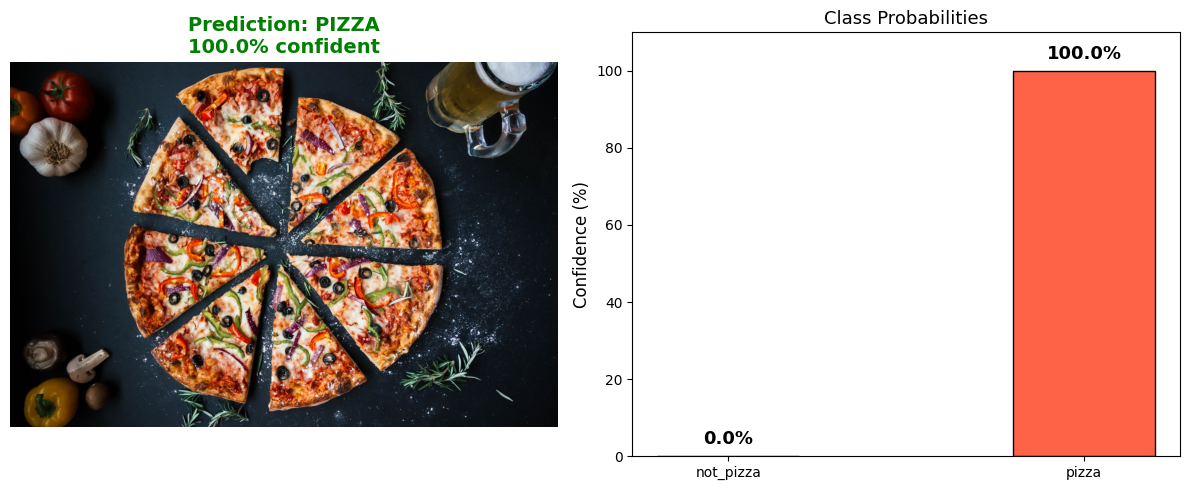

Prediction: pizza (100.0%)


In [91]:
image_dir = 'pizza_image.jpg'

predict_image(image_dir)